# Train AI2 – Vaccine Demand Forecast

`data/vaccine_demand.csv` → `models/demand_forecast.joblib`

Mô hình: **XGBoost Regressor** (time-series features: lag, rolling mean, calendar).

In [7]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA = ROOT / 'data' / 'vaccine_demand.csv'
MODEL_DIR = ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)
print(ROOT, DATA.exists())

d:\TTTN\Vaxcare\vaxcare-ai True


## 1. Load & khám phá

In [8]:
df = pd.read_csv(DATA, parse_dates=['date'])
print(df.shape)
print(df['date'].min(), '→', df['date'].max())
print('Số cặp facility–vaccine:', df.groupby(['facility_id', 'vaccine_id']).ngroups)
df.head()

(5460, 20)
2026-05-01 00:00:00 → 2026-06-04 00:00:00
Số cặp facility–vaccine: 156


,date,facility_id,facility_name,vaccine_id,vaccine_name,category_id,required_doses,dose_interval_days,average_rating,total_bookings_baseline,price,day_of_week,month,is_weekend,usage_count,current_stock,days_to_expiry,near_expiry,alert_threshold,low_stock
0,2026-05-01,1,VaxCare Phú Nhuận,1,Vắc xin BCG (Bacille Calmette–Guérin),1,1,0,4.9,860,250000,4,5,0,7,290,405,0,50,0
1,2026-05-01,1,VaxCare Phú Nhuận,2,Vắc xin Viêm gan B (Hepatitis B),1,3,30,4.8,1420,350000,4,5,0,13,345,584,0,50,0
2,2026-05-01,1,VaxCare Phú Nhuận,3,Vắc xin Bạch hầu – Ho gà – Uốn ván (DTaP/Tdap),2,5,60,4.9,1180,520000,4,5,0,12,205,624,0,50,0
3,2026-05-01,1,VaxCare Phú Nhuận,4,Vắc xin Bại liệt (IPV),1,4,60,4.8,930,390000,4,5,0,9,230,687,0,50,0
4,2026-05-01,1,VaxCare Phú Nhuận,5,Vắc xin Hib (Haemophilus influenzae type b),1,3,60,4.9,760,420000,4,5,0,10,181,373,0,50,0


In [9]:
df['usage_count'].describe()

count    5460.000000
mean        8.827656
std         5.582252
min         0.000000
25%         5.000000
50%         8.000000
75%        11.000000
max        50.000000
Name: usage_count, dtype: float64

## 2. Feature engineering

In [10]:
FEATURE_COLS = [
    'lag_1', 'lag_7', 'lag_14',
    'roll_mean_7', 'roll_mean_14',
    'day_of_week', 'month', 'is_weekend',
]

frames = []
for (fac, vac), g in df.groupby(['facility_id', 'vaccine_id']):
    g = g.set_index('date').sort_index()
    full = pd.date_range(g.index.min(), g.index.max(), freq='D')
    g = g.reindex(full)
    g['usage_count'] = g['usage_count'].fillna(0)
    g['facility_id'] = fac
    g['vaccine_id'] = vac
    g['day_of_week'] = g.index.dayofweek
    g['month'] = g.index.month
    g['is_weekend'] = (g.index.dayofweek >= 5).astype(int)
    g['lag_1'] = g['usage_count'].shift(1)
    g['lag_7'] = g['usage_count'].shift(7)
    g['lag_14'] = g['usage_count'].shift(14)
    g['roll_mean_7'] = g['usage_count'].shift(1).rolling(7, min_periods=1).mean()
    g['roll_mean_14'] = g['usage_count'].shift(1).rolling(14, min_periods=1).mean()
    g = g.dropna(subset=['lag_1', 'lag_7']).copy()
    frames.append(g.reset_index().rename(columns={'index': 'date'}))

prepared = pd.concat(frames, ignore_index=True)
print('Prepared:', prepared.shape)
prepared[FEATURE_COLS + ['usage_count']].head()

Prepared: (4368, 25)


,lag_1,lag_7,lag_14,roll_mean_7,roll_mean_14,day_of_week,month,is_weekend,usage_count
0,11.0,7.0,NaN,7.714286,7.714286,4,5,0,10
1,10.0,6.0,NaN,8.142857,8.000000,5,5,1,5
2,5.0,6.0,NaN,8.000000,7.666667,6,5,1,4
3,4.0,8.0,NaN,7.714286,7.300000,0,5,0,10
4,10.0,9.0,NaN,8.000000,7.545455,1,5,0,7


## 3. Train / Test split (theo thời gian)

In [11]:
cutoff = prepared['date'].quantile(0.8)
train_df = prepared[prepared['date'] <= cutoff]
test_df = prepared[prepared['date'] > cutoff]

X_train, y_train = train_df[FEATURE_COLS], train_df['usage_count']
X_test, y_test = test_df[FEATURE_COLS], test_df['usage_count']
print(f'Train: {len(X_train):,}  Test: {len(X_test):,}')

Train: 3,588  Test: 780


## 4. Train XGBoost

In [12]:
model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

pred = np.clip(model.predict(X_test), 0, None)
mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
r2 = r2_score(y_test, pred)
mape = np.mean(np.abs((y_test - pred) / np.maximum(y_test, 1))) * 100

print(f'MAE  : {mae:.3f}')
print(f'RMSE : {rmse:.3f}')
print(f'R2   : {r2:.3f}')
print(f'MAPE : {mape:.2f}%')

MAE  : 2.098
RMSE : 3.166
R2   : 0.682
MAPE : 23.91%


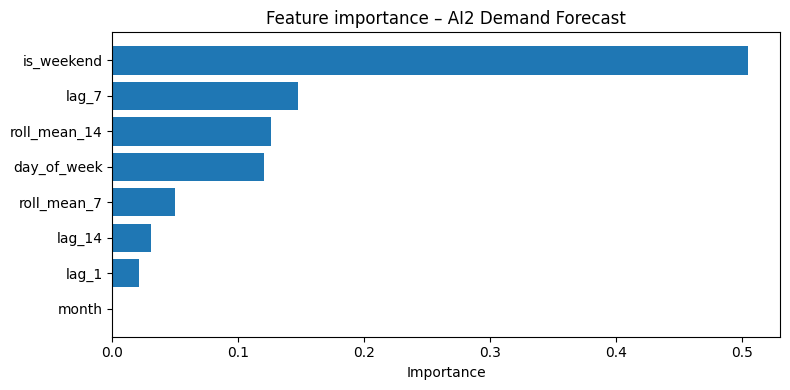

In [13]:
imp = sorted(zip(FEATURE_COLS, model.feature_importances_), key=lambda x: -x[1])
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([n for n, _ in imp][::-1], [v for _, v in imp][::-1])
ax.set_xlabel('Importance')
ax.set_title('Feature importance – AI2 Demand Forecast')
plt.tight_layout()
plt.show()

## 5. Lưu model

In [14]:
artifact = {
    'model': model,
    'feature_cols': FEATURE_COLS,
    'model_version': 'ai2-xgboost-v1',
    'metrics': {'mae': float(mae), 'rmse': float(rmse), 'r2': float(r2), 'mape': float(mape)},
}
out = MODEL_DIR / 'demand_forecast.joblib'
joblib.dump(artifact, out)
print('Saved →', out)

Saved → d:\TTTN\Vaxcare\vaxcare-ai\models\demand_forecast.joblib
